# Lecture 7 Demo — Preference learning in a gridworld (robust visuals)

This notebook is built for a live lecture:
- **Connected** start→goal corridors (two near-optimal routes)
- **Preference noise slider** (Bradley–Terry temperature `beta`)
- **Stable reward learning** (regularization + clipping)
- **Clear plots**: shaping heatmaps (goal removed), overlaid paths, policy arrows

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Widgets are optional. If not available, everything still runs.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

np.random.seed(0)

## 1) Gridworld MDP

In [ ]:
H, W = 12, 12
gamma = 0.97
start = (0, 0)
goal = (H-1, W-1)

A = [(0,1),(1,0),(0,-1),(-1,0)]  # R, D, L, U

def step(s, a):
    return (
        min(H-1, max(0, s[0] + a[0])),
        min(W-1, max(0, s[1] + a[1]))
    )

## 2) True reward with **two connected corridors** (near tie)

In [ ]:
def make_true_reward(H, W):
    r = np.zeros((H, W), dtype=np.float64)

    # Keep the goal reward on the same order as shaping so heatmaps remain interpretable.
    r[H-1, W-1] = 0.05

    # Corridor A (slightly better): top row → right column
    for j in range(1, W):
        r[0, j] += 0.0200
    for i in range(1, H):
        r[i, W-1] += 0.0200

    # Corridor B (slightly worse): left column → bottom row
    for i in range(1, H):
        r[i, 0] += 0.0196
    for j in range(1, W):
        r[H-1, j] += 0.0196

    # Mild negative strip to create a trade-off region
    for i in range(3, H-3):
        r[i, W//2] -= 0.004

    return r

r_true = make_true_reward(H, W)

## 3) Plot helpers (robust scaling + overlays)

In [ ]:
def plot_heatmap(r, title, ax=None, vmin=None, vmax=None, robust=True):
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(6,6))

    if robust and (vmin is None and vmax is None):
        lo, hi = np.percentile(r, [5, 95])
        if np.isclose(lo, hi):
            lo, hi = float(r.min()), float(r.max())
        vmin, vmax = lo, hi

    im = ax.imshow(r, origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.scatter([start[1]],[start[0]], s=140, marker="o", edgecolor="k", label="start")
    ax.scatter([goal[1]],[goal[0]], s=140, marker="X", edgecolor="k", label="goal")
    ax.legend(loc="upper left", framealpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    return ax

def overlay_path(ax, path, label, lw=2.8):
    xs, ys = zip(*path)
    ax.plot(ys, xs, linewidth=lw, marker="o", markersize=3, label=label)
    ax.legend(loc="lower right", framealpha=0.85)

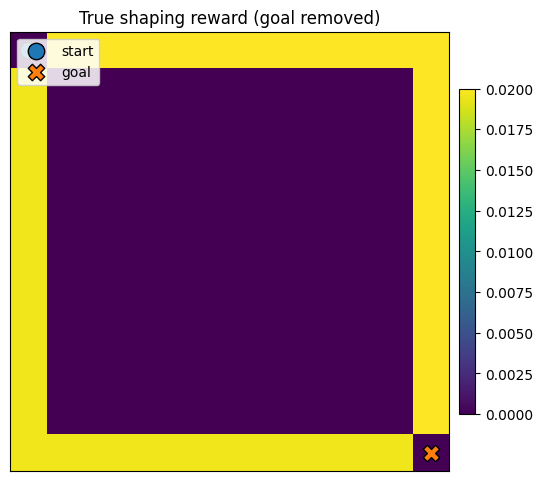

In [ ]:
# Show the true shaping reward (goal removed) so corridors are visible.
r_true_shaping = r_true.copy()
r_true_shaping[goal] = 0.0

fig, ax = plt.subplots(1,1, figsize=(6,6))
plot_heatmap(r_true_shaping, "True shaping reward (goal removed)", ax=ax, robust=True)
plt.show()

## 4) Generate trajectories (mixture of random + weak goal-directed)

In [ ]:
def random_policy(_s):
    return A[np.random.randint(4)]

def weak_goal_policy(s):
    # Bias moves towards goal, with some randomness
    i, j = s
    moves = []
    if j < W-1: moves.append((0,1))
    if i < H-1: moves.append((1,0))
    if j > 0:   moves.append((0,-1))
    if i > 0:   moves.append((-1,0))
    # choose a move that reduces L1 distance if possible
    d0 = abs(goal[0]-i) + abs(goal[1]-j)
    good = []
    for a in moves:
        ni, nj = step(s, a)
        d1 = abs(goal[0]-ni) + abs(goal[1]-nj)
        if d1 <= d0:
            good.append(a)
    pool = good if (len(good)>0 and np.random.rand()<0.85) else moves
    return pool[np.random.randint(len(pool))]

def rollout(policy, T=30):
    s = start
    traj = [s]
    for _ in range(T):
        s = step(s, policy(s))
        traj.append(s)
        if s == goal:
            break
    return traj

def generate_trajectories(n=160, T=30, mix=0.6):
    trajs = []
    for _ in range(n):
        pol = weak_goal_policy if np.random.rand() < mix else random_policy
        trajs.append(rollout(pol, T=T))
    return trajs

trajectories = generate_trajectories()
len(trajectories), len(trajectories[0])

(160, 27)

## 5) Preferences (Bradley–Terry with temperature `beta`)

In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def R(traj, r):
    return sum((gamma**t) * r[s] for t, s in enumerate(traj))

def make_preferences(trajs, r_star, n_pairs=3000, beta=0.2):
    m = len(trajs)
    prefs = []
    for _ in range(n_pairs):
        i = np.random.randint(m)
        j = np.random.randint(m-1)
        if j >= i: j += 1
        Ri, Rj = R(trajs[i], r_star), R(trajs[j], r_star)
        p = sigmoid((Ri - Rj) / max(beta, 1e-8))
        y = 1 if (np.random.rand() < p) else 0  # 1 means i preferred over j
        prefs.append((i, j, y))
    return prefs

## 6) Learn a tabular reward from preferences (stable)

In [ ]:
def learn_reward_from_preferences(trajs, prefs, H, W, lr=0.02, iters=10, l2=2e-2, clip=0.03):
    theta = np.zeros((H, W), dtype=np.float64)

    # discounted state visitation features per trajectory
    feats = []
    for traj in trajs:
        f = np.zeros((H, W), dtype=np.float64)
        for t, s in enumerate(traj):
            f[s] += (gamma**t)
        feats.append(f)

    for _ in range(iters):
        np.random.shuffle(prefs)
        for i, j, y in prefs:
            Ri = np.sum(theta * feats[i])
            Rj = np.sum(theta * feats[j])
            p = sigmoid(Ri - Rj)

            g = (y - p)
            grad = g * (feats[i] - feats[j]) - l2 * theta
            grad = np.clip(grad, -clip, clip)
            theta += lr * grad

        # shift invariance
        theta -= theta.mean()

    return theta

def align_affine(r_hat, r_ref, mask=None):
    x = r_hat.reshape(-1)
    y = r_ref.reshape(-1)
    if mask is not None:
        m = mask.reshape(-1).astype(bool)
        x, y = x[m], y[m]
    X = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(X, y, rcond=None)[0]
    return a * r_hat + b, (a, b)

## 7) Control: value iteration + greedy path + policy arrows

In [ ]:
def value_iteration(r, iters=350):
    V = np.zeros((H, W), dtype=np.float64)
    for _ in range(iters):
        V_new = V.copy()
        for i in range(H):
            for j in range(W):
                V_new[i, j] = max(r[i, j] + gamma * V[step((i, j), a)] for a in A)
        V = V_new
    return V

def greedy_path_from_V(V, r, T=60):
    s = start
    path = [s]
    for _ in range(T):
        a = max(A, key=lambda a: r[s] + gamma * V[step(s, a)])
        s = step(s, a)
        path.append(s)
        if s == goal:
            break
    return path

def plot_policy_arrows(V, r, title, ax=None, stride=1, vmin=None, vmax=None):
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(6,6))
    im = ax.imshow(r, origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.scatter([start[1]],[start[0]], s=140, marker="o", edgecolor="k")
    ax.scatter([goal[1]],[goal[0]], s=140, marker="X", edgecolor="k")
    for i in range(0, H, stride):
        for j in range(0, W, stride):
            a = max(A, key=lambda a: r[i, j] + gamma * V[step((i, j), a)])
            ax.arrow(j, i, a[1]*0.28, a[0]*0.28, head_width=0.16, head_length=0.16)
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    return ax

## 8) One-click demo runner (+ widgets)

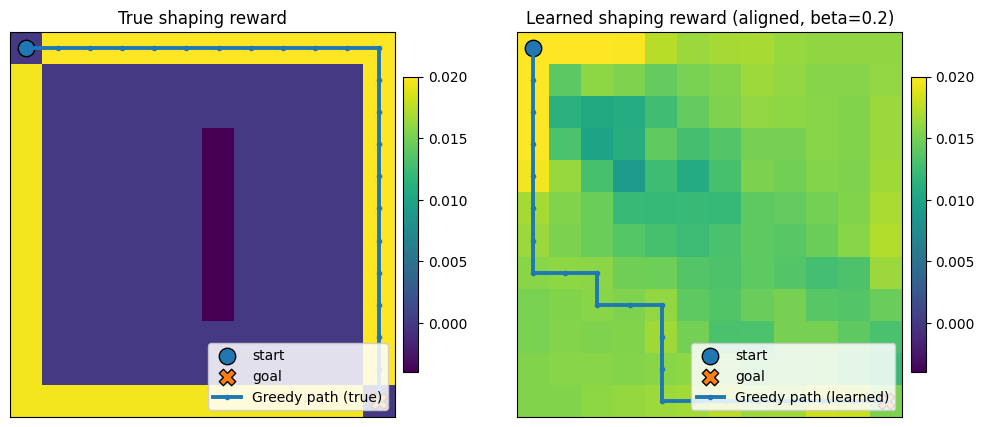

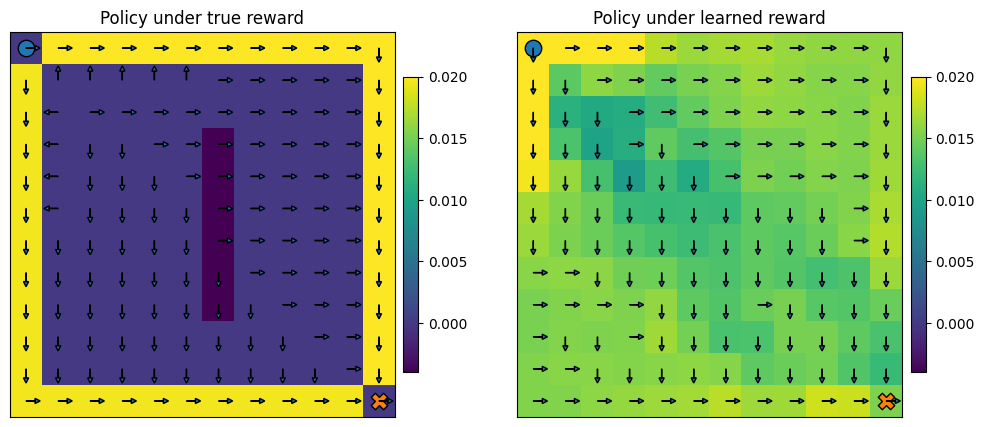

affine align: a=0.046, b=0.015
max shaping error: raw=0.2976, aligned=0.0230
path length: true=23, learned=23


Output()

In [ ]:
def run(beta=0.2, n_pairs=3000):
    prefs = make_preferences(trajectories, r_true, n_pairs=n_pairs, beta=beta)
    r_hat = learn_reward_from_preferences(trajectories, prefs, H, W, lr=0.02, iters=10)

    # compare shaping only for visualization
    r_true_shaping = r_true.copy(); r_true_shaping[goal] = 0.0
    r_hat_shaping  = r_hat.copy();  r_hat_shaping[goal]  = 0.0

    # affine-align (preferences identify reward up to shift/scale in practice)
    mask = (r_true_shaping != 0)
    r_hat_aligned, (a,b) = align_affine(r_hat_shaping, r_true_shaping, mask=mask)

    # control reward: use aligned shaping + true goal reward
    r_learned = r_hat_aligned.copy()
    r_learned[goal] = r_true[goal]

    V_true = value_iteration(r_true)
    V_learned = value_iteration(r_learned)

    p_true = greedy_path_from_V(V_true, r_true)
    p_learned = greedy_path_from_V(V_learned, r_learned)

    # Shared scale for shaping heatmaps
    vmin, vmax = float(r_true_shaping.min()), float(r_true_shaping.max())

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_heatmap(r_true_shaping, "True shaping reward", ax=ax[0], vmin=vmin, vmax=vmax, robust=False)
    overlay_path(ax[0], p_true, "Greedy path (true)")

    plot_heatmap(r_hat_aligned, f"Learned shaping reward (aligned, beta={beta})", ax=ax[1], vmin=vmin, vmax=vmax, robust=False)
    overlay_path(ax[1], p_learned, "Greedy path (learned)")
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_policy_arrows(V_true, r_true_shaping, "Policy under true reward", ax=ax[0], stride=1, vmin=vmin, vmax=vmax)
    plot_policy_arrows(V_learned, r_hat_aligned, "Policy under learned reward", ax=ax[1], stride=1, vmin=vmin, vmax=vmax)
    plt.show()

    raw_err = np.max(np.abs(r_hat_shaping - r_true_shaping))
    aligned_err = np.max(np.abs(r_hat_aligned - r_true_shaping))
    print(f"affine align: a={a:.3f}, b={b:.3f}")
    print(f"max shaping error: raw={raw_err:.4f}, aligned={aligned_err:.4f}")
    print(f"path length: true={len(p_true)}, learned={len(p_learned)}")

# quick run
run(beta=0.2, n_pairs=3000)

# Widget setup
if HAS_WIDGETS:
    beta_slider = widgets.FloatSlider(value=0.2, min=0.02, max=0.8, step=0.02, description="beta", continuous_update=False)
    pair_slider = widgets.IntSlider(value=3000, min=800, max=10000, step=200, description="pairs", continuous_update=False)
    ui = widgets.HBox([beta_slider, pair_slider])
    out = widgets.interactive_output(run, {"beta": beta_slider, "n_pairs": pair_slider})
    display(ui, out)
else:
    print("ipywidgets not available. Use run(beta=..., n_pairs=...)")

### Widgets (optional)

In [ ]:
# This cell is now redundant as its content has been merged into the previous cell.

In [ ]:
def run(beta=0.2, n_pairs=3000):
    prefs = make_preferences(trajectories, r_true, n_pairs=n_pairs, beta=beta)
    r_hat = learn_reward_from_preferences(trajectories, prefs, H, W, lr=0.02, iters=10)

    # compare shaping only for visualization
    r_true_shaping = r_true.copy(); r_true_shaping[goal] = 0.0
    r_hat_shaping  = r_hat.copy();  r_hat_shaping[goal]  = 0.0

    # affine-align (preferences identify reward up to shift/scale in practice)
    mask = (r_true_shaping != 0)
    r_hat_aligned, (a,b) = align_affine(r_hat_shaping, r_true_shaping, mask=mask)

    # control reward: use aligned shaping + true goal reward
    r_learned = r_hat_aligned.copy()
    r_learned[goal] = r_true[goal]

    V_true = value_iteration(r_true)
    V_learned = value_iteration(r_learned)

    p_true = greedy_path_from_V(V_true, r_true)
    p_learned = greedy_path_from_V(V_learned, r_learned)

    # Shared scale for shaping heatmaps
    vmin, vmax = float(r_true_shaping.min()), float(r_true_shaping.max())

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_heatmap(r_true_shaping, "True shaping reward", ax=ax[0], vmin=vmin, vmax=vmax, robust=False)
    overlay_path(ax[0], p_true, "Greedy path (true)")

    plot_heatmap(r_hat_aligned, f"Learned shaping reward (aligned, beta={beta})", ax=ax[1], vmin=vmin, vmax=vmax, robust=False)
    overlay_path(ax[1], p_learned, "Greedy path (learned)")
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_policy_arrows(V_true, r_true_shaping, "Policy under true reward", ax=ax[0], stride=1, vmin=vmin, vmax=vmax)
    plot_policy_arrows(V_learned, r_hat_aligned, "Policy under learned reward", ax=ax[1], stride=1, vmin=vmin, vmax=vmax)
    plt.show()

    print(f"affine align: a={a:.3f}, b={b:.3f}")
    print(f"path length: true={len(p_true)}, learned={len(p_learned)}")

# Widget setup
if HAS_WIDGETS:
    beta_slider = widgets.FloatSlider(value=0.2, min=0.02, max=0.8, step=0.02, description='beta', continuous_update=False)
    pair_slider = widgets.IntSlider(value=3000, min=800, max=10000, step=200, description='pairs', continuous_update=False)
    ui = widgets.HBox([beta_slider, pair_slider])
    out = widgets.interactive_output(run, {'beta': beta_slider, 'n_pairs': pair_slider})
    display(ui, out)
else:
    run(beta=0.2, n_pairs=3000)

Output()